# 3.2 — Regression Modelling (from 2.2 data-preparation UMAP/MICE)

This notebook performs a comprehensive regression modelling workflow using the prepared dataset output from `2.2-data-preparation-UMAP-Mice.ipynb` (train/test parquet files). 

Goals:

1. Load cleaned data.
2. Explore target and features.
3. Build and evaluate regression models.
4. Produce explainable output (feature importance + SHAP optionally).
5. Save best model and metrics.

In [1]:
# 1. Imports and global setup
import os
from pathlib import Path

import pandas as pd
import numpy as np
import polars as pl

from sklearn.model_selection import train_test_split, RepeatedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

# Optional explainability library
try:
    import shap
except Exception:
    shap = None

pd.options.display.max_columns = 200
pd.options.display.precision = 4

print('Libraries loaded. SHAP installed:', shap is not None)

Libraries loaded. SHAP installed: False


In [2]:
# 2. Load data from parquet outputs


# Polars to pandas for sklearn convenience
train_pl = pl.read_parquet(f"./data/interim/2.2-train.parquet")
test_pl = pl.read_parquet(f"./data/interim/2.2-test.parquet")

print('Train shape:', train_pl.shape)
print('Test shape:', test_pl.shape)

train_df = train_pl.to_pandas()
test_df = test_pl.to_pandas()

print('Top columns:', list(train_df.columns[:20]))

# quick view for 5 rows
display(train_df.head())

Train shape: (111388, 48)
Test shape: (27848, 48)
Top columns: ['Arthritis', 'Cancer', 'Circulation', 'Depression', 'Diabetes', 'Heart Disease', 'High Bp', 'Kidney Disease', 'Liver Disease', 'Lung Disease', 'Nervous System', 'Stroke', 'Pre-Op Q Assisted', 'Pre-Op Q Previous Surgery', 'Age Band', 'Gender', 'Pre-Op Q Symptom Period', 'Pre-Op Q Mobility', 'Pre-Op Q Self-Care', 'Pre-Op Q Activity']


,Arthritis,Cancer,Circulation,Depression,Diabetes,Heart Disease,High Bp,Kidney Disease,Liver Disease,Lung Disease,Nervous System,Stroke,Pre-Op Q Assisted,Pre-Op Q Previous Surgery,Age Band,Gender,Pre-Op Q Symptom Period,Pre-Op Q Mobility,Pre-Op Q Self-Care,Pre-Op Q Activity,Pre-Op Q Discomfort,Pre-Op Q Anxiety,Pre-Op Q EQ5D Index,Post-Op Q EQ5D Index,Knee Replacement Pre-Op Q Pain,Knee Replacement Pre-Op Q Night Pain,Knee Replacement Pre-Op Q Washing,Knee Replacement Pre-Op Q Transport,Knee Replacement Pre-Op Q Walking,Knee Replacement Pre-Op Q Standing,Knee Replacement Pre-Op Q Limping,Knee Replacement Pre-Op Q Kneeling,Knee Replacement Pre-Op Q Work,Knee Replacement Pre-Op Q Confidence,Knee Replacement Pre-Op Q Shopping,Knee Replacement Pre-Op Q Stairs,Knee Replacement Post-Op Q Score,Pre-Op Q Living Arrangements,Pre-Op Q Disability,Provider Code,Procedure,Revision Flag,Year,Pre-Op Q Assisted By,Knee Replacement Pre-Op Q Score,Pre-Op Q EQ5D Index Profile,Post-Op Q EQ5D Index Profile,health_gain
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,3.0,2.0,1.0,2.0,2.0,2.0,3.0,2.0,-0.016,1.0000,0.0,0.0,2.0,2.0,2.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,40.0,1.0,1.0,294.0,1.0,0.0,3.0,1.0,9.0,22232,11111,31.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,4.0,1.0,2.0,1.0,1.0,1.0,2.0,1.0,0.796,0.7600,1.0,2.0,4.0,4.0,2.0,3.0,2.0,2.0,3.0,3.0,4.0,3.0,29.0,1.0,2.0,183.0,1.0,0.0,3.0,1.0,33.0,11121,11221,-4.0
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,4.0,1.0,2.0,1.0,1.0,1.0,2.0,1.0,0.796,1.0000,1.0,3.0,4.0,4.0,2.0,3.0,2.0,2.0,3.0,3.0,3.0,3.0,35.0,1.0,2.0,267.0,1.0,0.0,1.0,1.0,33.0,11121,11111,2.0
3,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,4.0,1.0,4.0,2.0,1.0,2.0,2.0,1.0,0.691,0.6910,0.0,0.0,3.0,2.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,43.0,1.0,1.0,274.0,1.0,0.0,2.0,1.0,11.0,21221,21221,32.0
4,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,3.0,2.0,2.0,2.0,1.0,2.0,2.0,1.0,0.691,0.9065,1.0,1.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,3.0,3.0,3.0,43.0,1.0,1.0,156.0,1.0,0.0,1.0,1.0,26.0,21221,11291,17.0


## 3. Data overview and missingness

In [3]:
# Null counts
print('Train nulls:')
print(train_df.isna().sum()[train_df.isna().sum() > 0].sort_values(ascending=False))
print('\nTest nulls:')
print(test_df.isna().sum()[test_df.isna().sum() > 0].sort_values(ascending=False))

# Basic descriptive stats
print('\nTrain numeric stats:')
print(train_df.describe().T.head(20))

Train nulls:
Series([], dtype: int64)

Test nulls:
Series([], dtype: int64)

Train numeric stats:
                              count    mean     std     min  25%  50%  75%  \
Arthritis                  111388.0  0.7695  0.4211  0.0000  1.0  1.0  1.0   
Cancer                     111388.0  0.0542  0.2264  0.0000  0.0  0.0  0.0   
Circulation                111388.0  0.0568  0.2314  0.0000  0.0  0.0  0.0   
Depression                 111388.0  0.0941  0.2920  0.0000  0.0  0.0  0.0   
Diabetes                   111388.0  0.1251  0.3308  0.0000  0.0  0.0  0.0   
Heart Disease              111388.0  0.0940  0.2919  0.0000  0.0  0.0  0.0   
High Bp                    111388.0  0.4417  0.4966  0.0000  0.0  0.0  1.0   
Kidney Disease             111388.0  0.0204  0.1415  0.0000  0.0  0.0  0.0   
Liver Disease              111388.0  0.0058  0.0759  0.0000  0.0  0.0  0.0   
Lung Disease               111388.0  0.0923  0.2894  0.0000  0.0  0.0  0.0   
Nervous System             111388.0  0.0105 

### 3.1 Select regression target

Typical targets in this pipeline are:
- `Hip Replacement Post-Op Q Score` (continuous)
- `Hip Replacement Pre-Op Q Score` normally pre-existing
- `OHS_Success` is binary (classification), so we will keep this aside.

We will model post-op score as a regression target.

Selected target: health_gain


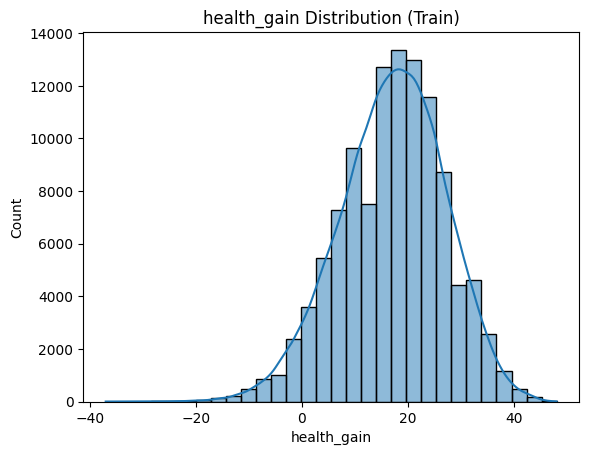

Target stats (train): count    111388.0000
mean         17.0267
std           9.9236
min         -37.0000
25%          11.0000
50%          17.0980
75%          24.0000
max          48.0000
Name: health_gain, dtype: float64
Top 15 positive correlations with target:
Knee Replacement Post-Op Q Score    0.6729
Post-Op Q EQ5D Index                0.4643
Pre-Op Q Discomfort                 0.2677
Pre-Op Q Activity                   0.1794
Pre-Op Q Mobility                   0.1608
Pre-Op Q Self-Care                  0.0838
Pre-Op Q Previous Surgery           0.0786
Gender                              0.0426
Year                                0.0336
Arthritis                           0.0264
Age Band                            0.0195
Pre-Op Q Anxiety                    0.0174
Pre-Op Q Symptom Period             0.0068
High Bp                             0.0048
Cancer                              0.0008
Name: health_gain, dtype: float64

Top 15 negative correlations with target:
Knee Replace

C:\Users\mittall\AppData\Local\Temp\ipykernel_3036\2149507075.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pd.DataFrame({'corr': top_pos.values, 'feature': top_pos.index}),


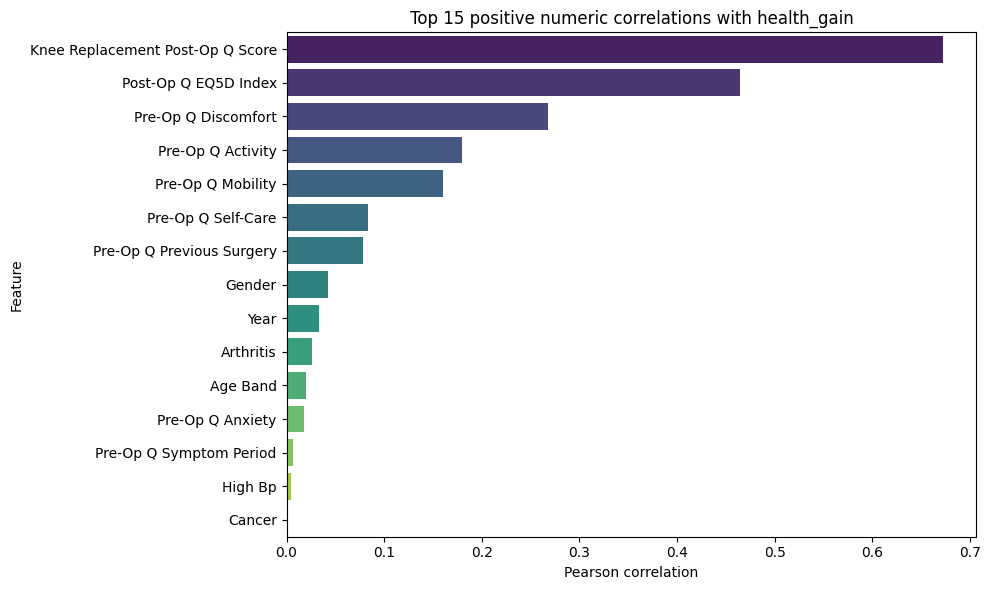

C:\Users\mittall\AppData\Local\Temp\ipykernel_3036\2149507075.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pd.DataFrame({'corr': top_neg.values, 'feature': top_neg.index}),


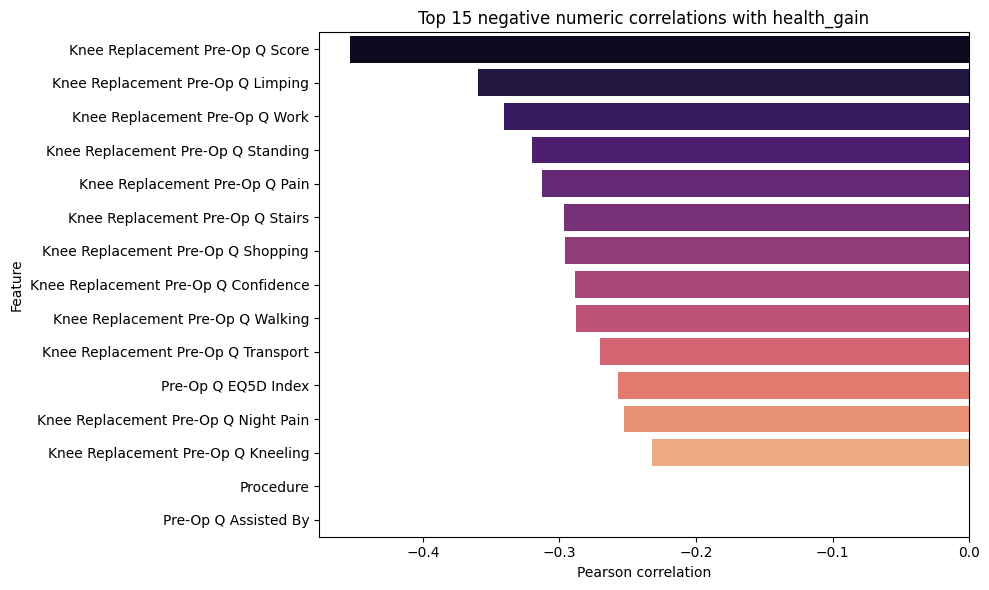

In [4]:
# Determine available target (prefer Health Gain)
candidates = [
    'health_gain'
]

target = next((c for c in candidates if c in train_df.columns), None)
if target is None:
    raise RuntimeError('No known regression target in data columns.')

print('Selected target:', target)

# If the target is already present in the test split this is regression evaluation directly.

# Check distribution
sns.histplot(train_df[target].dropna(), kde=True, bins=30)
plt.title(f'{target} Distribution (Train)')
plt.ylabel('Count'); plt.xlabel(target)
plt.show()

print('Target stats (train):', train_df[target].describe())

# Correlation analysis: health gain (or selected numeric target) vs numeric predictors
corr_df = train_df.select_dtypes(include=['number']).corr()[target].drop(index=[target]).sort_values(ascending=False)
print('Top 15 positive correlations with target:')
print(corr_df.head(15))
print('\nTop 15 negative correlations with target:')
print(corr_df.tail(15))

plt.figure(figsize=(10, 6))
top_pos = corr_df.head(15)
sns.barplot(data=pd.DataFrame({'corr': top_pos.values, 'feature': top_pos.index}), 
            x='corr', y='feature', palette='viridis')
plt.title(f'Top 15 positive numeric correlations with {target}')
plt.xlabel('Pearson correlation')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
top_neg = corr_df.tail(15).sort_values()  # sort ascending so negative values appear correctly
sns.barplot(data=pd.DataFrame({'corr': top_neg.values, 'feature': top_neg.index}), 
            x='corr', y='feature', palette='magma')
plt.title(f'Top 15 negative numeric correlations with {target}')
plt.xlabel('Pearson correlation')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### 3.2 Feature matrix construction

In [5]:
# Remove target and known non-predictive columns
drop_cols = [target, 'OHS_Success'] if 'OHS_Success' in train_df.columns else [target]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df[target]

# Identify numeric and categorical features
numeric_cols = X_train.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print('Numeric features:', len(numeric_cols), 'Categorical features:', len(cat_cols))
print('Sample numeric cols:', numeric_cols[:15])
print('Sample categorical cols:', cat_cols[:10])

Numeric features: 45 Categorical features: 2
Sample numeric cols: ['Arthritis', 'Cancer', 'Circulation', 'Depression', 'Diabetes', 'Heart Disease', 'High Bp', 'Kidney Disease', 'Liver Disease', 'Lung Disease', 'Nervous System', 'Stroke', 'Pre-Op Q Assisted', 'Pre-Op Q Previous Surgery', 'Age Band']
Sample categorical cols: ['Pre-Op Q EQ5D Index Profile', 'Post-Op Q EQ5D Index Profile']


In [6]:
# If there are categorical columns, attempt one-hot encoding and imputation
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

transformers_list = []

# Add numeric transformer if numeric columns exist
if numeric_cols:
    transformers_list.append(('num', numeric_transformer, numeric_cols))

# Add categorical transformer if categorical columns exist
if cat_cols:
    categorical_transformer = Pipeline(
        steps=[
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]
    )
    transformers_list.append(('cat', categorical_transformer, cat_cols))

# Create preprocessor with at least one transformer
if transformers_list:
    preprocessor = ColumnTransformer(
        transformers=transformers_list,
        remainder='drop'
    )
else:
    raise ValueError("No numeric or categorical columns found!")

print('Preprocessor configured.')

Preprocessor configured.


## 4. Regression models training + evaluation

Compare baseline and tree-based models with cross-validation and final test set metrics.

In [7]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'Lasso': Lasso(alpha=0.01, random_state=42, max_iter=10000),
    'RandomForest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=300, random_state=42)
}

cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
scoring = {'MAE':'neg_mean_absolute_error', 'RMSE':'neg_root_mean_squared_error', 'R2':'r2'}

results = []

for name, model in models.items():
    pipeline_model = Pipeline([('pre', preprocessor), ('model', model)])
    cv_res = cross_validate(pipeline_model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)

    results.append({
        'model': name,
        'MAE': -cv_res['test_MAE'].mean(),
        'RMSE': -cv_res['test_RMSE'].mean(),
        'R2': cv_res['test_R2'].mean()
    })

cv_results_df = pd.DataFrame(results).sort_values('RMSE')
cv_results_df

,model,MAE,RMSE,R2
0,LinearRegression,5.0591e-14,6.3086e-14,1.0000
1,Ridge,1.8895e-04,4.7150e-04,1.0000
2,Lasso,1.4114e-02,1.7629e-02,1.0000
3,RandomForest,9.4713e-03,8.9836e-02,0.9999
4,GradientBoosting,1.6513e-01,2.2207e-01,0.9995


## 5. Final fit on train, evaluate on test set

In [9]:
# Choose best model by RMSE in CV
best_name = cv_results_df.sort_values('RMSE').iloc[0]['model']
best_estimator = models[best_name]
print('Best candidate:', best_name)

best_pipeline = Pipeline([('pre', preprocessor), ('model', best_estimator)])
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('Test results:')
print('MAE:', mae)
print('RMSE:', rmse)
print('R2:', r2)

# Save test metrics
test_metrics = pd.DataFrame([{
    'model': best_name,
    'MAE': mae,
    'RMSE': rmse,
    'R2': r2
}])

display(test_metrics)


Best candidate: LinearRegression
Test results:
MAE: 4.8323055155477323e-14
RMSE: 6.183877929581864e-14
R2: 1.0


,model,MAE,RMSE,R2
0,LinearRegression,4.8323e-14,6.1839e-14,1.0


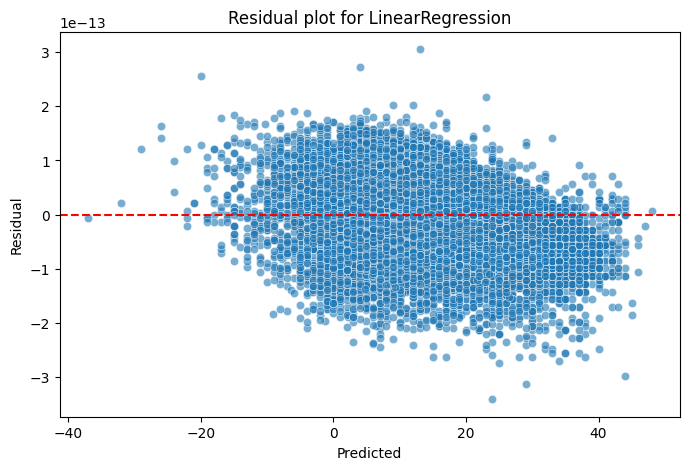

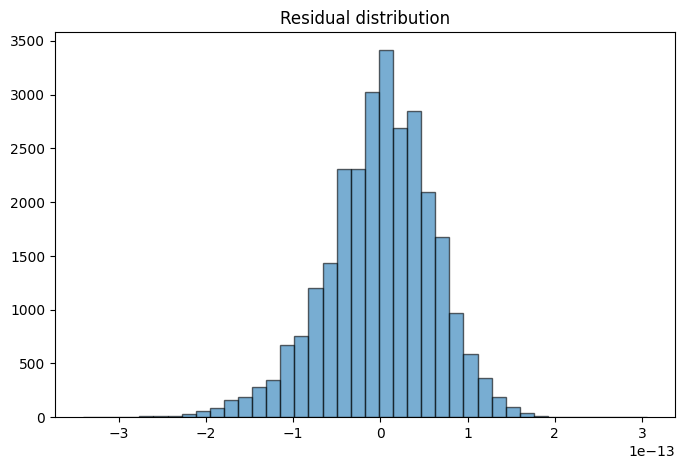

In [10]:
# Residual analysis
resid = y_test - y_pred
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=resid, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residual')
plt.title(f'Residual plot for {best_name}')
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(resid, bins=40, edgecolor='k', alpha=0.6)
plt.title('Residual distribution')
plt.show()

## 6. Explainability (feature importance + SHAP)

Top 25 features by absolute coefficient:


Knee Replacement Post-Op Q Score      9.4572e+00
Knee Replacement Pre-Op Q Score      -7.8496e+00
Pre-Op Q EQ5D Index Profile_11119     2.2307e-13
Pre-Op Q EQ5D Index Profile_11133    -1.6559e-13
Pre-Op Q EQ5D Index Profile_11113    -1.5957e-13
Pre-Op Q EQ5D Index Profile_11192     1.1558e-13
Pre-Op Q EQ5D Index Profile_11191    -1.0426e-13
Pre-Op Q EQ5D Index Profile_11213    -8.3204e-14
Post-Op Q EQ5D Index Profile_22991   -7.9649e-14
Pre-Op Q EQ5D Index Profile_11139    -7.1997e-14
Pre-Op Q EQ5D Index Profile_11199    -5.4514e-14
Pre-Op Q EQ5D Index Profile_11932    -4.2870e-14
Post-Op Q EQ5D Index                 -4.0690e-14
Pre-Op Q EQ5D Index Profile_11311    -3.7819e-14
Pre-Op Q EQ5D Index Profile_11239    -3.2366e-14
Pre-Op Q EQ5D Index Profile_12311    -3.1563e-14
Pre-Op Q EQ5D Index Profile_11991    -3.1438e-14
Pre-Op Q EQ5D Index Profile_13121    -3.1242e-14
Pre-Op Q EQ5D Index Profile_12131    -2.8728e-14
Pre-Op Q EQ5D Index Profile_11339    -2.8691e-14
Pre-Op Q EQ5D Index 

C:\Users\mittall\AppData\Local\Temp\ipykernel_3036\4067707301.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top25.values, y=top25.index, palette=colors)


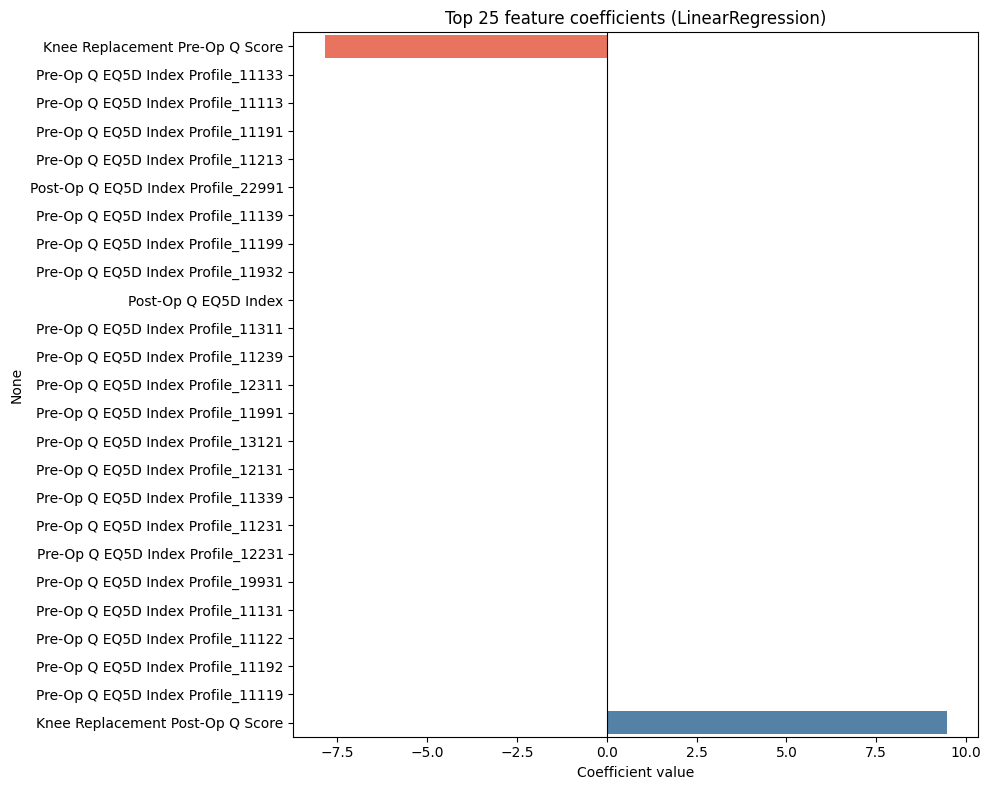

SHAP not detected — restart the kernel and re-run all cells to activate it.


In [13]:
# Reconstruct feature names after preprocessing
onehot_cols = []
if cat_cols:
    encoder = best_pipeline.named_steps['pre'].named_transformers_['cat'].named_steps['onehot']
    cat_names = encoder.get_feature_names_out(cat_cols)
    onehot_cols = cat_names.tolist()
feature_names = numeric_cols + onehot_cols

model_step = best_pipeline.named_steps['model']

# Feature importance for tree models
if hasattr(model_step, 'feature_importances_'):
    importances = pd.Series(model_step.feature_importances_, index=feature_names).sort_values(ascending=False)
    print('Top 25 feature importances:')
    display(importances.head(25))

    plt.figure(figsize=(10, 6))
    sns.barplot(x=importances.head(20), y=importances.head(20).index)
    plt.title(f'Top 20 feature importances ({best_name})')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

# Coefficients for linear models
elif hasattr(model_step, 'coef_'):
    coef = pd.Series(model_step.coef_, index=feature_names)
    coef_abs = coef.abs().sort_values(ascending=False)
    print('Top 25 features by absolute coefficient:')
    display(coef.loc[coef_abs.head(25).index])

    top25 = coef.loc[coef_abs.head(25).index].sort_values()
    plt.figure(figsize=(10, 8))
    colors = ['tomato' if v < 0 else 'steelblue' for v in top25]
    sns.barplot(x=top25.values, y=top25.index, palette=colors)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.title(f'Top 25 feature coefficients ({best_name})')
    plt.xlabel('Coefficient value')
    plt.tight_layout()
    plt.show()

else:
    print('No feature importance or coefficients available for', best_name)

# SHAP analysis if available and model supports
if shap is not None:
    print('Running SHAP explanation (takes a moment)...')
    X_train_transformed = best_pipeline.named_steps['pre'].transform(X_train)
    X_test_transformed = best_pipeline.named_steps['pre'].transform(X_test)
    explainer = shap.Explainer(model_step, X_train_transformed)
    shap_values = explainer(X_test_transformed)

    shap.summary_plot(shap_values, feature_names=feature_names, plot_type='bar', show=True)
    shap.summary_plot(shap_values, feature_names=feature_names, show=True)
else:
    print('SHAP not detected — restart the kernel and re-run all cells to activate it.')


## 7. Save best pipeline and metrics

In [15]:
import joblib
out_dir = Path('./models')
out_dir.mkdir(parents=True, exist_ok=True)

pipe_path = out_dir / f'3.2-best-regressor-{best_name}.joblib'
metrics_path = out_dir / '3.2-regression-metrics.csv'

joblib.dump(best_pipeline, pipe_path)
print('Saved best model to', pipe_path)

test_metrics.to_csv(metrics_path, index=False)
print('Saved test metrics to', metrics_path)

Saved best model to models\3.2-best-regressor-LinearRegression.joblib
Saved test metrics to models\3.2-regression-metrics.csv


## 8. Dummy Patient Prediction & Explanation

Simulate a single patient using median/mode values from the training data, run it through the best model, and explain **why** the model predicts that specific health gain.


=== Dummy Patient Profile ===


,Value
Arthritis,1.0
Cancer,0.0
Circulation,0.0
Depression,0.0
Diabetes,0.0
Heart Disease,0.0
High Bp,0.0
Kidney Disease,0.0
Liver Disease,0.0
Lung Disease,0.0



>>> Predicted Health Gain: 19.0000
    Average health gain in training data: 17.0267
    This patient is ABOVE average by 1.9733 points

=== Top 5 features INCREASING the predicted health gain ===
  + Knee Replacement Post-Op Q Score              raw=np.float64(38.0)  contribution=+2.1453
  + Pre-Op Q EQ5D Index Profile_21221             raw='encoded'   contribution=+0.0000
  + Pre-Op Q Anxiety                              raw=np.float64(1.0)  contribution=+0.0000
  + Gender                                        raw=np.float64(2.0)  contribution=+0.0000
  + Heart Disease                                 raw=np.float64(0.0)  contribution=+0.0000

=== Top 5 features DECREASING the predicted health gain ===
  - Knee Replacement Pre-Op Q Score               raw=np.float64(19.0)  contribution=-0.1719
  - Pre-Op Q Discomfort                           raw=np.float64(2.0)  contribution=-0.0000
  - Pre-Op Q Self-Care                            raw=np.float64(1.0)  contribution=-0.0000
  - Knee

C:\Users\mittall\AppData\Local\Temp\ipykernel_3036\3594335874.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=contributions[sorted_contrib.index].values,


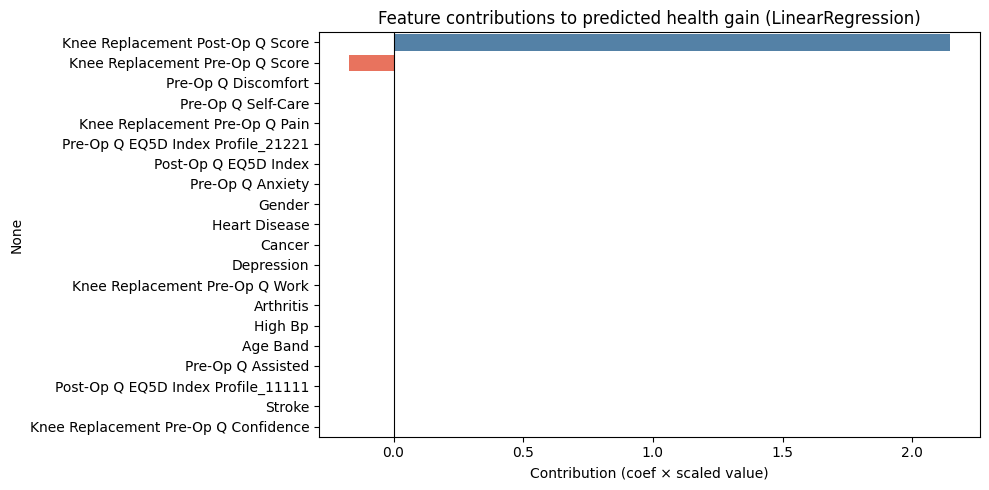


Tip: restart kernel and re-run to enable SHAP waterfall explanation.

=== Plain English Summary ===
The model predicts this patient will gain 19.00 points on the knee health score after surgery.
This is higher than the average patient gain of 17.03.
The most influential features (shown above) are the ones that pushed the prediction up or down the most.


In [16]:
# ── Build a dummy patient using median (numeric) and mode (categorical) from training data ──
dummy = {}
for col in numeric_cols:
    dummy[col] = [X_train[col].median()]
for col in cat_cols:
    dummy[col] = [X_train[col].mode()[0]]

dummy_df = pd.DataFrame(dummy)

print("=== Dummy Patient Profile ===")
display(dummy_df.T.rename(columns={0: 'Value'}))

# ── Predict health gain ──
predicted_gain = best_pipeline.predict(dummy_df)[0]
print(f"\n>>> Predicted Health Gain: {predicted_gain:.4f}")

avg_gain = y_train.mean()
diff = predicted_gain - avg_gain
direction = "ABOVE" if diff > 0 else "BELOW"
print(f"    Average health gain in training data: {avg_gain:.4f}")
print(f"    This patient is {direction} average by {abs(diff):.4f} points\n")

# ── Explain WHY: show top feature contributions ──
model_step = best_pipeline.named_steps['model']

if hasattr(model_step, 'coef_'):
    # Linear model: contribution = coef * scaled_value
    transformed = best_pipeline.named_steps['pre'].transform(dummy_df)[0]
    contributions = pd.Series(model_step.coef_ * transformed, index=feature_names)
    top_pos = contributions.sort_values(ascending=False).head(5)
    top_neg = contributions.sort_values().head(5)

    print("=== Top 5 features INCREASING the predicted health gain ===")
    for feat, val in top_pos.items():
        raw_val = dummy_df[feat].values[0] if feat in dummy_df.columns else "encoded"
        print(f"  + {feat:<45} raw={raw_val!r:<10}  contribution={val:+.4f}")

    print("\n=== Top 5 features DECREASING the predicted health gain ===")
    for feat, val in top_neg.items():
        raw_val = dummy_df[feat].values[0] if feat in dummy_df.columns else "encoded"
        print(f"  - {feat:<45} raw={raw_val!r:<10}  contribution={val:+.4f}")

    # Bar chart of all contributions
    plt.figure(figsize=(10, 5))
    sorted_contrib = contributions.abs().sort_values(ascending=False).head(20)
    colors = ['steelblue' if contributions[f] >= 0 else 'tomato' for f in sorted_contrib.index]
    sns.barplot(x=contributions[sorted_contrib.index].values,
                y=sorted_contrib.index, palette=colors)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.title(f'Feature contributions to predicted health gain ({best_name})')
    plt.xlabel('Contribution (coef × scaled value)')
    plt.tight_layout()
    plt.show()

elif hasattr(model_step, 'feature_importances_'):
    importances = pd.Series(model_step.feature_importances_, index=feature_names).sort_values(ascending=False)
    print("=== Top 10 most important features for this model ===")
    for feat, imp in importances.head(10).items():
        raw_val = dummy_df[feat].values[0] if feat in dummy_df.columns else "encoded"
        print(f"  {feat:<45} patient_value={raw_val!r:<10}  importance={imp:.4f}")

# ── SHAP waterfall for this single patient (if available) ──
if shap is not None:
    X_train_t = best_pipeline.named_steps['pre'].transform(X_train)
    X_dummy_t = best_pipeline.named_steps['pre'].transform(dummy_df)
    explainer = shap.Explainer(model_step, X_train_t)
    shap_vals = explainer(X_dummy_t)

    print("\n=== SHAP Waterfall: step-by-step explanation for the dummy patient ===")
    shap.plots.waterfall(shap_vals[0], max_display=15, show=True)
else:
    print("\nTip: restart kernel and re-run to enable SHAP waterfall explanation.")

print("\n=== Plain English Summary ===")
print(f"The model predicts this patient will gain {predicted_gain:.2f} points on the knee health score after surgery.")
print(f"This is {'higher' if diff > 0 else 'lower'} than the average patient gain of {avg_gain:.2f}.")
print("The most influential features (shown above) are the ones that pushed the prediction up or down the most.")
